# Redevelopment Regression

A logistic regression that scores every residential parcel in Waltham by its
probability of being redeveloped in the near future.

**Label definition:** a parcel "turned over" between two consecutive assessment
snapshots if its `MAX(YEAR_BUILT)` increased and the new value is within 3 years
of the newer snapshot year. New construction on previously vacant lots
(`YEAR_BUILT` was 0 in the old snapshot) is also counted.

**Training data:** all consecutive assessment snapshot pairs from 2011→2014
through 2022→2023 (10 pairs). Features come from the *older* snapshot;
labels are determined by comparing it to the *newer* snapshot.

**Temporal split:** train on pairs ending ≤ 2021, validate on pairs ending in
2022 and 2023. The 2025 snapshot is held out for scoring only.

**`YEAR_BUILT = 0`** (no recorded build date) is treated as `snapshot_year − 75`,
i.e. we assume the structure is 75 years old.

In [11]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import branca.colormap as cm

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

from investigations.development_regression import fetch

## Build labeled dataset

For each consecutive snapshot pair (through 2022→2023), fetch features from the
older snapshot and label each parcel based on whether it turned over before the
newer snapshot.

In [ ]:
frames = []
# Accumulates every LOC_ID that has turned over so far; these are excluded
# from all subsequent snapshot pairs and from the 2025 scoring.
ever_redeveloped = set()

# Use pairs through 2022→2023; hold out 2025 and 2026 for scoring
training_pairs = [(tbl_old, tbl_new, yr_old, yr_new, taxpar_old, taxpar_new)
                  for tbl_old, tbl_new, yr_old, yr_new, taxpar_old, taxpar_new
                  in fetch.CONSECUTIVE_PAIRS
                  if yr_new <= 2023]

for tbl_old, tbl_new, yr_old, yr_new, taxpar_old, taxpar_new in training_pairs:
    print(f"Fetching {yr_old}→{yr_new}...", end=" ", flush=True)
    features = fetch.fetch_features_for_snapshot(tbl_old, yr_old, par_table=taxpar_old)
    labels = fetch.fetch_turnover_labels(
        tbl_old, tbl_new, yr_new,
        taxpar_old=taxpar_old, taxpar_new=taxpar_new,
    )

    # Drop parcels already redeveloped in any prior period
    features = features[~features["LOC_ID"].isin(ever_redeveloped)]

    features["turnover"] = features["LOC_ID"].isin(labels["LOC_ID"]).astype(int)
    features = features.merge(labels[["LOC_ID", "via_merger"]], on="LOC_ID", how="left")
    features["via_merger"] = features["via_merger"].fillna(False)
    features["label_year"] = yr_new
    frames.append(features)
    n_pos = features["turnover"].sum()
    n_merger = (features["via_merger"] & (features["turnover"] == 1)).sum()
    print(f"{len(features):,} parcels, {n_pos} turned over ({n_pos/len(features)*100:.1f}%), {n_merger} via merger")

    ever_redeveloped.update(set(labels["LOC_ID"]))

data = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows: {len(data):,} | Positives: {data['turnover'].sum()} ({data['turnover'].mean()*100:.2f}%)")
print(f"Via merger positives: {(data['via_merger'] & (data['turnover'] == 1)).sum()}")
print(f"Parcels excluded as previously redeveloped: {len(ever_redeveloped)}")

## Merger redevelopment analysis

Parcels flagged `via_merger` were absorbed into a merged lot that then showed a
new `YEAR_BUILT`. For each such parcel, query the new-snapshot assess table to
see what was built: USE_CODE, building area, units.

In [ ]:
from sqlalchemy import text as _text
from data.connect_db import get_db as _get_db

merger_outcomes = []

for tbl_old, tbl_new, yr_old, yr_new, taxpar_old, taxpar_new in training_pairs:
    if taxpar_old is None or taxpar_new is None:
        continue
    pair_key = f"{yr_old}→{yr_new}"
    pair_data = data[(data["label_year"] == yr_new) & data["via_merger"] & (data["turnover"] == 1)]
    if pair_data.empty:
        continue
    ids = tuple(pair_data["LOC_ID"].tolist())
    ids_sql = f"('{ids[0]}')" if len(ids) == 1 else str(ids)

    sql = _text(f"""
        SELECT
            tp_old."LOC_ID"                   AS old_loc_id,
            MIN(a_new."USE_CODE"::integer)     AS use_code,
            MAX(a_new."BLD_AREA")              AS bld_area,
            SUM(a_new."UNITS")                 AS units,
            MAX(a_new."SITE_ADDR")             AS site_addr
        FROM "{taxpar_old}" tp_old
        JOIN "{taxpar_new}" tp_new
            ON ST_Within(ST_Centroid(tp_old.geom), tp_new.geom)
        JOIN "{tbl_new}" a_new ON a_new."LOC_ID" = tp_new."LOC_ID"
        WHERE tp_old."POLY_TYPE" = 'FEE'
          AND tp_new."POLY_TYPE" = 'FEE'
          AND tp_old."LOC_ID" IN {ids_sql}
        GROUP BY tp_old."LOC_ID"
    """)
    engine = _get_db()
    with engine.connect() as conn:
        result = pd.read_sql(sql, conn)
    result["pair"] = pair_key
    merger_outcomes.append(result)

if merger_outcomes:
    merger_df = pd.concat(merger_outcomes, ignore_index=True)
    print(f"{len(merger_df)} merger redevelopments with outcome data\n")
    print("USE_CODE distribution (101=SFH, 102=condo, 104=2-fam, 105=3-fam):")
    print(merger_df["use_code"].value_counts().to_string())
    print(f"\nMedian resulting BLD_AREA: {merger_df['bld_area'].median():,.0f} sq ft")
    print(f"Median resulting UNITS:    {merger_df['units'].median():.0f}")
    print()
    print(merger_df[["pair", "old_loc_id", "site_addr", "use_code", "bld_area", "units"]]
          .sort_values("bld_area", ascending=False)
          .to_string(index=False))
else:
    print("No merger outcomes found — check that training pairs have taxpar tables.")

## EDA: feature distributions by outcome

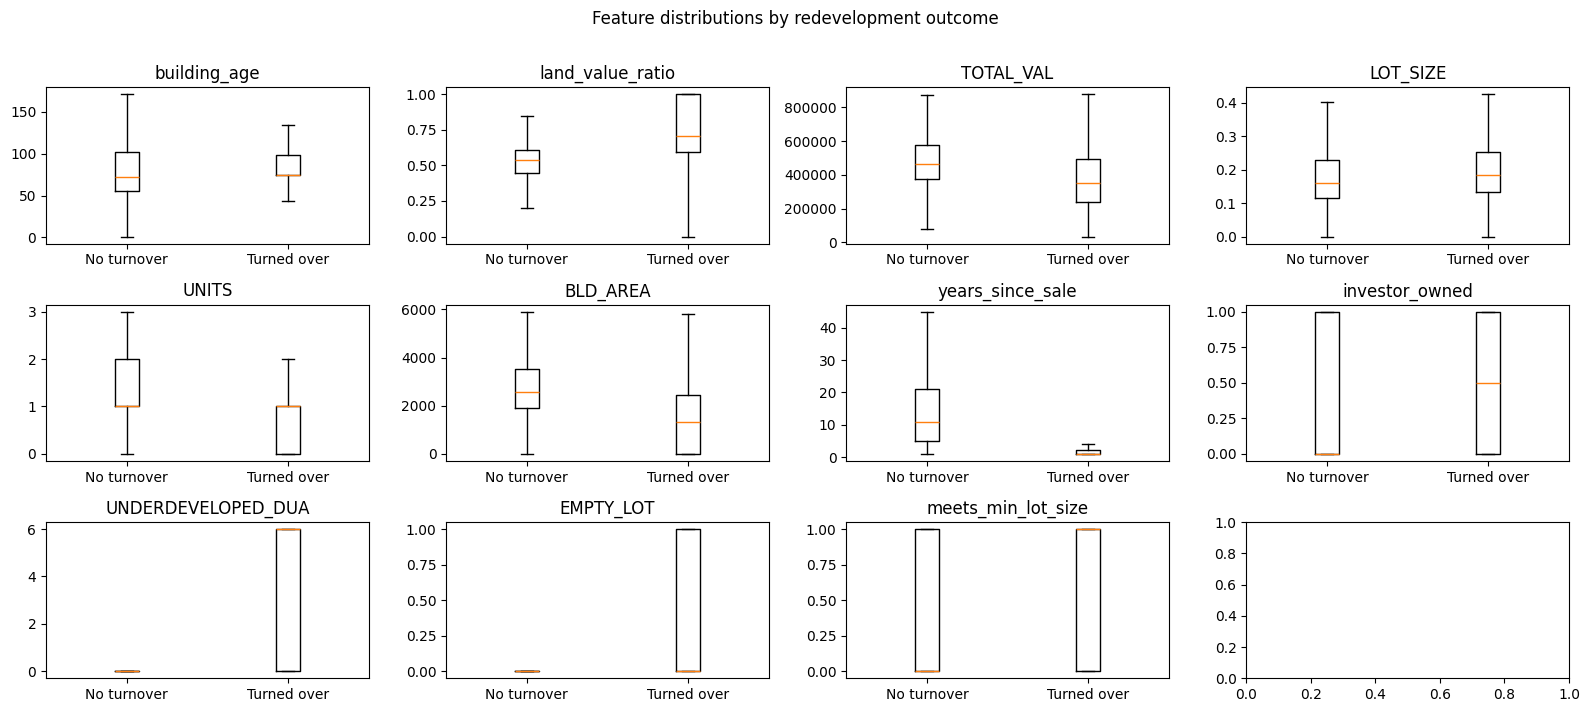

In [13]:
numeric_features = [
    "building_age", "land_value_ratio", "TOTAL_VAL",
    "LOT_SIZE", "UNITS", "BLD_AREA", "years_since_sale", "investor_owned", "UNDERDEVELOPED_DUA", "EMPTY_LOT", "meets_min_lot_size",
]
categorical_features = ["zone"]

fig, axes = plt.subplots(3, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    groups = [data.loc[data["turnover"] == 0, col].dropna(),
              data.loc[data["turnover"] == 1, col].dropna()]
    ax.boxplot(groups, tick_labels=["No turnover", "Turned over"], showfliers=False)
    ax.set_title(col)

plt.suptitle("Feature distributions by redevelopment outcome", y=1.01)
plt.tight_layout()
plt.show()

## Train logistic regression

**Temporal split:** train on snapshot pairs ending ≤ 2021, validate on pairs
ending in 2022–2023. This mirrors real-world usage — the model is trained on
historical data and evaluated on data it has never seen.

In [14]:
train = data[data["label_year"] <= 2021]
val   = data[data["label_year"] >= 2022]

print(f"Train: {len(train):,} rows ({train['turnover'].sum()} positive)")
print(f"Val:   {len(val):,} rows ({val['turnover'].sum()} positive)")

feature_cols = numeric_features + categorical_features
X_train, y_train = train[feature_cols], train["turnover"]
X_val,   y_val   = val[feature_cols],   val["turnover"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(class_weight="balanced", max_iter=500)),
])

model.fit(X_train, y_train)
print("Model trained.")

Train: 94,485 rows (296 positive)
Val:   23,413 rows (78 positive)
Model trained.


In [15]:
val_probs = model.predict_proba(X_val)[:, 1]
val_preds = model.predict(X_val)

auc = roc_auc_score(y_val, val_probs)
print(f"Validation AUC-ROC: {auc:.3f}\n")
print(classification_report(y_val, val_preds, target_names=["No turnover", "Turned over"]))

Validation AUC-ROC: 0.896

              precision    recall  f1-score   support

 No turnover       1.00      0.89      0.94     23335
 Turned over       0.02      0.73      0.04        78

    accuracy                           0.88     23413
   macro avg       0.51      0.81      0.49     23413
weighted avg       1.00      0.88      0.94     23413



## XGBoost model

Tree ensembles often outperform logistic regression on tabular data with severe
class imbalance. `scale_pos_weight` is set to the negative/positive ratio in the
training set, equivalent to `class_weight='balanced'` for logistic regression.
The scaler is omitted since XGBoost is scale-invariant; missing values are handled
natively by the tree splits.

In [16]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

xgb_model = Pipeline([
    ("preprocessor", xgb_preprocessor),
    ("classifier",   XGBClassifier(
        scale_pos_weight=neg / pos,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        verbosity=0,
    )),
])

xgb_model.fit(X_train, y_train)

xgb_probs = xgb_model.predict_proba(X_val)[:, 1]
xgb_preds = xgb_model.predict(X_val)
xgb_auc   = roc_auc_score(y_val, xgb_probs)

print(f"XGBoost            AUC-ROC: {xgb_auc:.3f}")
print(f"Logistic regression AUC-ROC: {auc:.3f}")
print()
print(classification_report(y_val, xgb_preds, target_names=["No turnover", "Turned over"]))

# Carry forward whichever model wins on validation AUC for scoring
if xgb_auc >= auc:
    best_model, best_name = xgb_model, "XGBoost"
else:
    best_model, best_name = model, "Logistic regression"
print(f"→ Using {best_name} for 2025 scoring.")

XGBoost            AUC-ROC: 0.926
Logistic regression AUC-ROC: 0.896

              precision    recall  f1-score   support

 No turnover       1.00      0.98      0.99     23335
 Turned over       0.06      0.44      0.11        78

    accuracy                           0.98     23413
   macro avg       0.53      0.71      0.55     23413
weighted avg       0.99      0.98      0.98     23413

→ Using XGBoost for 2025 scoring.


### SHAP feature effects

SHAP values explain how each feature pushes an individual prediction above or
below the baseline. The beeswarm plot shows every validation example as a dot:
position on the x-axis is the SHAP value (positive = raises P(redevelopment)),
color is the raw feature value (red = high, blue = low).

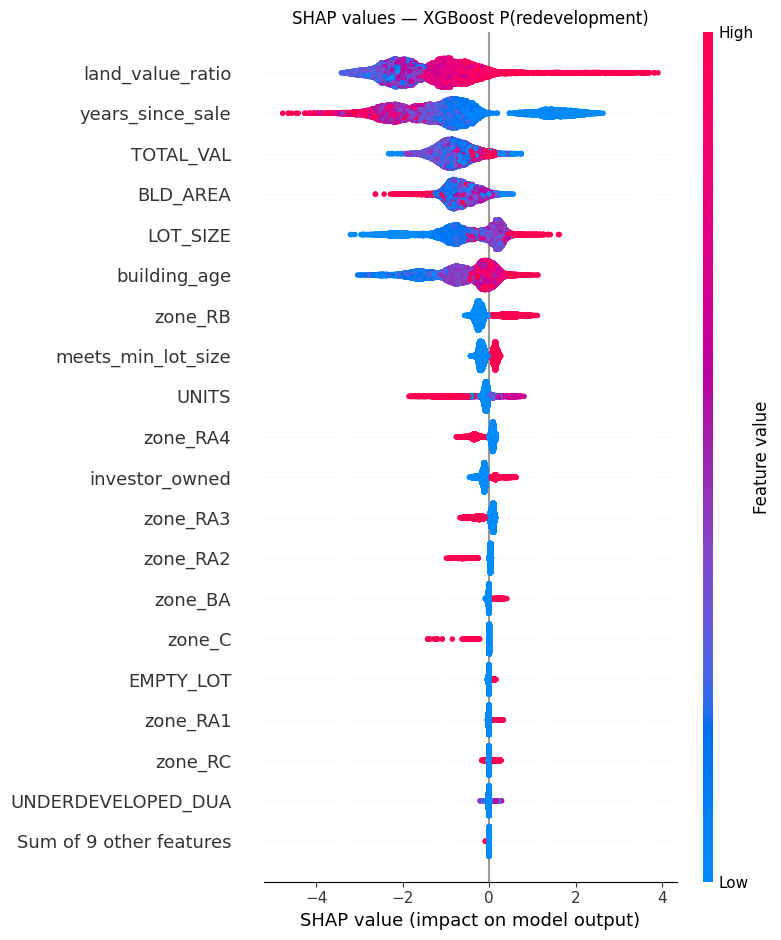

In [17]:
import shap

# Transform validation set through the preprocessor to get the feature matrix
# that the XGBoost classifier actually sees
X_val_transformed = xgb_model.named_steps["preprocessor"].transform(X_val)

# Recover feature names: numeric features keep their names; zone is one-hot expanded
zone_ohe_names = (
    xgb_model.named_steps["preprocessor"]
             .named_transformers_["cat"]
             .named_steps["onehot"]
             .get_feature_names_out(["zone"])
             .tolist()
)
transformed_feature_names = numeric_features + zone_ohe_names

explainer   = shap.TreeExplainer(xgb_model.named_steps["classifier"])
shap_values = explainer(X_val_transformed)
shap_values.feature_names = transformed_feature_names

shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP values — XGBoost P(redevelopment)")
plt.tight_layout()
plt.show()

## Feature importance: logistic regression coefficients

Coefficients are on standardized features, so magnitudes are comparable.
Positive = increases P(redevelopment), negative = decreases it.

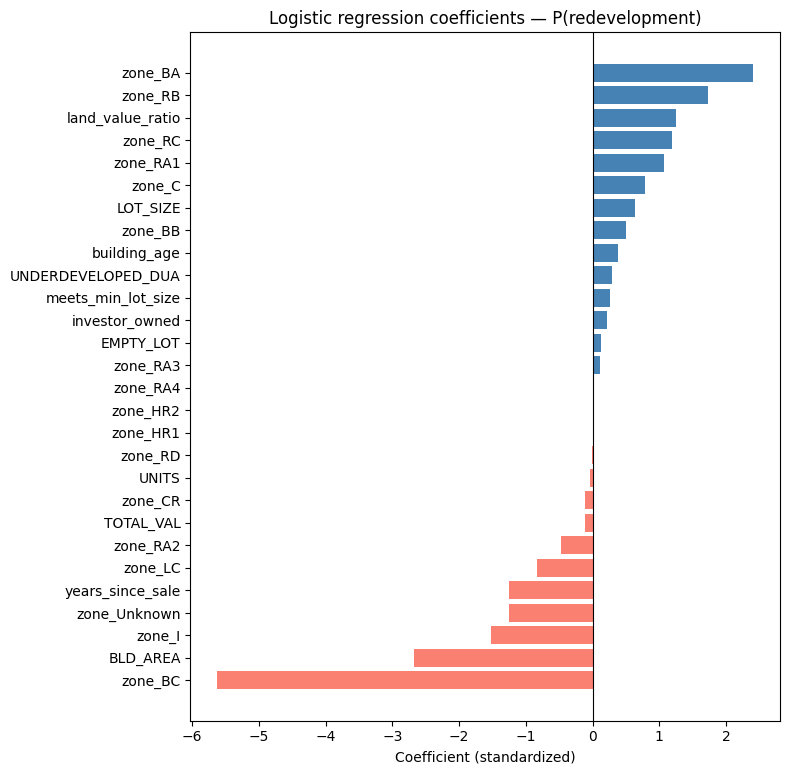

In [18]:
zone_feature_names = (
    model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .named_steps["onehot"]
         .get_feature_names_out(["zone"])
         .tolist()
)
feature_names = numeric_features + zone_feature_names
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefficients})
coef_df = coef_df.sort_values("coef")

fig, ax = plt.subplots(figsize=(8, max(4, len(coef_df) * 0.28)))
colors = ["steelblue" if c >= 0 else "salmon" for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardized)")
ax.set_title("Logistic regression coefficients — P(redevelopment)")
plt.tight_layout()
plt.show()

## Score 2025 snapshot

Apply the better-performing model (`best_model`) to the 2025 assessment snapshot
to rank all current residential parcels by their probability of redevelopment.

In [19]:
print("Fetching 2025 features...")
scored = fetch.fetch_features_for_snapshot("M308Assess_CY25_FY25", 2025)

# Exclude parcels redeveloped at any point during the training period
n_before = len(scored)
scored = scored[~scored["LOC_ID"].isin(ever_redeveloped)]
print(f"Excluded {n_before - len(scored)} previously-redeveloped parcels.")

scored["prob_redevelopment"] = best_model.predict_proba(scored[feature_cols])[:, 1]
scored = scored.sort_values("prob_redevelopment", ascending=False)

print(f"Scored {len(scored):,} residential parcels ({best_name}).")
print(f"Probability range: {scored['prob_redevelopment'].min():.3f} - {scored['prob_redevelopment'].max():.3f}")
scored[["LOC_ID", "SITE_ADDR", "zone", "building_age", "land_value_ratio", "LOT_SIZE", "prob_redevelopment"]].head(20)

Fetching 2025 features...
Excluded 283 previously-redeveloped parcels.
Scored 11,690 residential parcels (XGBoost).
Probability range: 0.000 - 0.997


,LOC_ID,SITE_ADDR,zone,building_age,land_value_ratio,LOT_SIZE,prob_redevelopment
9099,F_731097_2960311,7 SCHOOL AVE,RB,75.0,0.999997,0.14,0.996502
5704,F_726202_2975885,39 SHEFFIELD RD,RA3,75.0,0.999998,0.21,0.994782
9078,F_731068_2960257,3 SCHOOL AVE,RB,75.0,0.999997,0.14,0.994634
2917,F_724236_2964590,66 LAWRENCE ST,RA4,75.0,0.999998,0.19,0.992340
5083,F_725759_2971361,65 MONTCLAIR AVE,RA3,75.0,0.999997,0.15,0.992022
1489,F_722481_2961244,21 FISKE AVE,RA4,75.0,0.999998,0.16,0.991963
2089,F_723497_2960044,165 -7R SOUTH ST,RB,75.0,0.999996,0.15,0.991410
7852,F_728802_2958729,308 NEWTON ST,RB,75.0,0.999997,0.14,0.990739
7843,F_728791_2958677,312 NEWTON ST,RB,75.0,0.999997,0.14,0.990739
5813,F_726279_2970493,102 TRIMOUNT AVE,RA3,75.0,0.999997,0.09,0.990077


## Interactive map

Parcels colored by predicted probability of redevelopment. Darker red = higher
probability. The color scale is anchored to the 5th and 95th percentiles to
prevent extreme outliers from washing out the gradient.

In [ ]:
from investigations import StreetViewPanel

from branca.element import MacroElement
from jinja2 import Template

class ProbabilitySlider(MacroElement):
    """Leaflet control that shows/hides parcels below a probability threshold."""

    _template = Template("""
        {%- macro script(this, kwargs) %}
        var sliderCtrl_{{this._id}} = L.control({position: 'bottomleft'});
        sliderCtrl_{{this._id}}.onAdd = function(map) {
            var div = L.DomUtil.create('div');
            div.style.cssText = 'background:white;padding:10px 14px;border-radius:6px;'
                + 'box-shadow:0 2px 6px rgba(0,0,0,.35);min-width:230px;';
            div.innerHTML =
                '<div style="font-size:13px;font-weight:600;margin-bottom:6px;">'
                + 'Min P(redevelopment): <span id="prob-val-{{this._id}}">0.90</span></div>'
                + '<input id="prob-slider-{{this._id}}" type="range" min="0" max="1" '
                + 'step="0.01" value="0.9" style="width:100%;">'
            L.DomEvent.disableClickPropagation(div);
            L.DomEvent.disableScrollPropagation(div);
            return div;
        };
        sliderCtrl_{{this._id}}.addTo({{this._parent.get_name()}});

        document.getElementById('prob-slider-{{this._id}}').addEventListener('input', function() {
            var threshold = parseFloat(this.value);
            document.getElementById('prob-val-{{this._id}}').textContent = threshold.toFixed(2);
            {{this.layer_name}}.eachLayer(function(layer) {
                if (!layer.feature) return;
                var prob = layer.feature.properties.prob_redevelopment;
                var el = layer.getElement ? layer.getElement() : layer._path;
                if (el) el.style.display = (prob !== undefined && prob >= threshold) ? '' : 'none';
            });
        });
        setTimeout(function() {
            document.getElementById('prob-slider-{{this._id}}').dispatchEvent(new Event('input'));
        }, 0);
        {%- endmacro %}
    """)

    def __init__(self, layer_name):
        super().__init__()
        self._name = 'ProbabilitySlider'
        self.layer_name = layer_name


geom = fetch.fetch_parcel_geometry()
scored_gdf = geom.merge(scored[["LOC_ID", "prob_redevelopment", "building_age",
                                 "land_value_ratio", "LOT_SIZE", "years_since_sale",
                                 "zone", "investor_owned", "EMPTY_LOT", "SITE_ADDR"]],
                         on="LOC_ID", how="inner")
scored_gdf = scored_gdf.to_crs(epsg=4326)

# Parcels with YEAR_BUILT of 2024, 2025, or 2026 in the 2026 snapshot that
# were not already built in the 2023 snapshot.
actual_df = fetch.fetch_turnover_labels(
    "M308Assess_CY23_FY23", "M308Assess_CY26_FY26", 2026, min_year=2024,
    taxpar_old="M308TaxPar_CY23_FY23",  # no cy26 taxpar; falls back to LOC_ID for new side
)
actual_gdf = (
    geom[geom["LOC_ID"].isin(actual_df["LOC_ID"])]
    .merge(scored[["LOC_ID", "SITE_ADDR"]], on="LOC_ID", how="left")
    .merge(actual_df[["LOC_ID", "via_merger"]], on="LOC_ID", how="left")
    .to_crs(epsg=4326)
)
actual_gdf["via_merger"] = actual_gdf["via_merger"].fillna(False)
print(f"{len(actual_gdf)} parcels actually redeveloped (YEAR_BUILT 2024–2026), "
      f"{actual_gdf['via_merger'].sum()} via merger")

# Residential parcels from the 2023 taxpar whose LOC_ID is absent from the
# 2026 assessment — these were reorganized (subdivided, merged, renumbered).
disappeared_gdf = fetch.fetch_disappeared_parcels(
    "M308TaxPar_CY23_FY23", "M308Assess_CY23_FY23", "M308Assess_CY26_FY26"
).to_crs(epsg=4326)
print(f"{len(disappeared_gdf)} residential parcels with LOC_IDs absent from 2026 snapshot")

p05 = scored_gdf["prob_redevelopment"].quantile(0.05)
p95 = scored_gdf["prob_redevelopment"].quantile(0.95)

colormap = cm.LinearColormap(
    colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    vmin=p05, vmax=p95,
    caption="P(redevelopment)",
)

_bounds = scored_gdf.total_bounds
center = [(_bounds[1] + _bounds[3]) / 2, (_bounds[0] + _bounds[2]) / 2]
m = folium.Map(
    location=center,
    zoom_start=13,
    tiles="CartoDB positron",
    max_bounds=True,
    min_lat=_bounds[1] - 0.01,
    max_lat=_bounds[3] + 0.01,
    min_lon=_bounds[0] - 0.01,
    max_lon=_bounds[2] + 0.01,
)

def style_fn(feature):
    prob = feature["properties"]["prob_redevelopment"]
    return {
        "fillColor": colormap(max(p05, min(p95, prob))),
        "color": "#444444",
        "weight": 0.3,
        "fillOpacity": 0.75,
    }

tooltip = folium.GeoJsonTooltip(
    fields=["SITE_ADDR", "LOC_ID", "prob_redevelopment", "building_age",
            "land_value_ratio", "LOT_SIZE", "years_since_sale", "zone"],
    aliases=["Address", "LOC ID", "P(redevelopment)", "Building age (yrs)",
             "Land value ratio", "Lot size (ac)", "Yrs since sale", "Zone"],
    localize=True,
)

geojson_layer = folium.GeoJson(
    scored_gdf,
    style_function=style_fn,
    tooltip=tooltip,
    name="Redevelopment probability (2025)",
)
geojson_layer.add_to(m)

# Actual redevelopment: cyan outline, no fill — prediction colour shows through
actual_layer = folium.GeoJson(
    actual_gdf,
    style_function=lambda f: {
        "color": "#00e5ff",
        "weight": 4,
        "fillOpacity": 0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["SITE_ADDR", "LOC_ID", "via_merger"],
        aliases=["Address", "LOC ID", "Merged lot?"],
    ),
    name="Actual redevelopment (year built from 2024-2026)",
    show=True,
)
actual_layer.add_to(m)

# Reorganized parcels: orange dashed outline — LOC_ID present in 2023 but
# absent from 2026, suggesting subdivision, merger, or renumbering.
disappeared_layer = folium.GeoJson(
    disappeared_gdf,
    style_function=lambda f: {
        "color": "#ff9800",
        "weight": 3,
        "fillOpacity": 0,
        "dashArray": "6 3",
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["SITE_ADDR", "LOC_ID"],
        aliases=["Address", "LOC ID (2023)"],
    ),
    name="LOC_ID disappeared 2023→2026 (reorganized parcels)",
    show=True,
)
disappeared_layer.add_to(m)

ProbabilitySlider(geojson_layer.get_name()).add_to(m)
StreetViewPanel(
    geojson_layer.get_name(),
    extra_layers=[actual_layer.get_name(), disappeared_layer.get_name()],
).add_to(m)
colormap.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

m.save("published/development_regression.html")
print("Saved development_regression.html")
m